# Spatial Rainfall Regression Plot

This notebook plots the spatial regression of rainfall against Niño 3.4 for P1, P2, and their difference (P2 - P1).

### Plot Modification Guide:
To change the visualisation parameters or plot data, refer to the following variables in the code:
- **`reg_levels`** and **`reg_ticks`**: Control the value range, colour-contour interval, and colourbar ticks (-80 to 80).
- **`mc_extent`**: Sets the geographic bounds of the plot (format: `[lon_min, lon_max, lat_min, lat_max]`).
- **`mc_xticks`** and **`mc_yticks`**: Set intervals for longitude and latitude coordinate labels on the maps.
- **`subplots`** list (in the plot cell): Contains tuples with the plot axis (`ax`), data variable (`rain_reg_*`), significance variable (`rain_reg_*_sig`), and title for each subplot.
- **`gs`** (GridSpec): Sets a 2-row x 4-column layout; panels a-b span two columns in the top row, while panel c spans two central columns in the bottom row.
- **`subplot_wspace`**: Controls horizontal spacing between panels a and b. A larger value increases the gap; a smaller value brings the panels closer.
- **`subplot_hspace`**: Controls vertical spacing between the top row and panel c. A larger value moves panel c lower; a smaller value moves it higher.
- **`fig.subplots_adjust()`**: Controls the overall figure margins. `left/right` move the side bounds, while `bottom/top` control the lower and upper space.
- **`colorbar_extra_width`**: Extends the colourbar relative to panel c. For example, `0.10` adds 10% of the figure width, distributed equally to the left and right.
- **`colorbar_y_gap`**: Controls the vertical gap between the colourbar and panel c. A larger value moves the colourbar lower.
- **`colorbar_height`**: Controls colourbar thickness. A larger value makes it thicker.
- **`cax`** (Colourbar Axis): Uses the format `[x0, y0, width, height]` in figure coordinates from 0 to 1. `x0/y0` set the lower-left position and `width/height` set the size.
- **`rcParams`** in the import cell: Sets Helvetica (sans-serif) as the font and **16** as the default font size for all plot elements.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.ndimage import gaussian_filter

# Matplotlib configuration matching Fig. 2.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'figure.dpi': 150,
})

def smooth_for_plot(da, sigma=0.7):
    if not {"lat", "lon"}.issubset(da.dims):
        return da
    def _smooth(arr):
        return gaussian_filter(arr, sigma=sigma)
    smoothed = xr.apply_ufunc(
        _smooth,
        da,
        input_core_dims=[["lat", "lon"]],
        output_core_dims=[["lat", "lon"]],
        vectorize=True,
        dask="allowed",
        output_dtypes=[da.dtype],
    )
    smoothed = smoothed.transpose(*da.dims)
    smoothed = smoothed.assign_attrs(da.attrs)
    if da.name is not None:
        smoothed = smoothed.rename(da.name)
    return smoothed

SCRIPT_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/RegressionRainfall')
CACHE_DIR = SCRIPT_DIR
RESULTS_DIR = SCRIPT_DIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

reg_levels = np.arange(-80, 81, 4)
reg_ticks = np.arange(-80, 81, 20)

mc_extent = [80, 160, -20, 20]
mc_xticks = np.arange(90, 161, 20)
mc_yticks = np.arange(-20, 21, 10)

In [2]:
rain_ds = xr.open_dataset(CACHE_DIR / 'rainfall_reg_cache_1981_2025.nc')

rain_reg_past = rain_ds['rain_reg_past']
rain_reg_recent = rain_ds['rain_reg_recent']
rain_reg_recent_minus_past = rain_ds['rain_reg_recent_minus_past']

rain_reg_past_sig = rain_ds['rain_reg_past_sig']
rain_reg_recent_sig = rain_ds['rain_reg_recent_sig']
rain_reg_recent_minus_past_sig = rain_ds['rain_reg_recent_minus_past_sig']

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


...

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


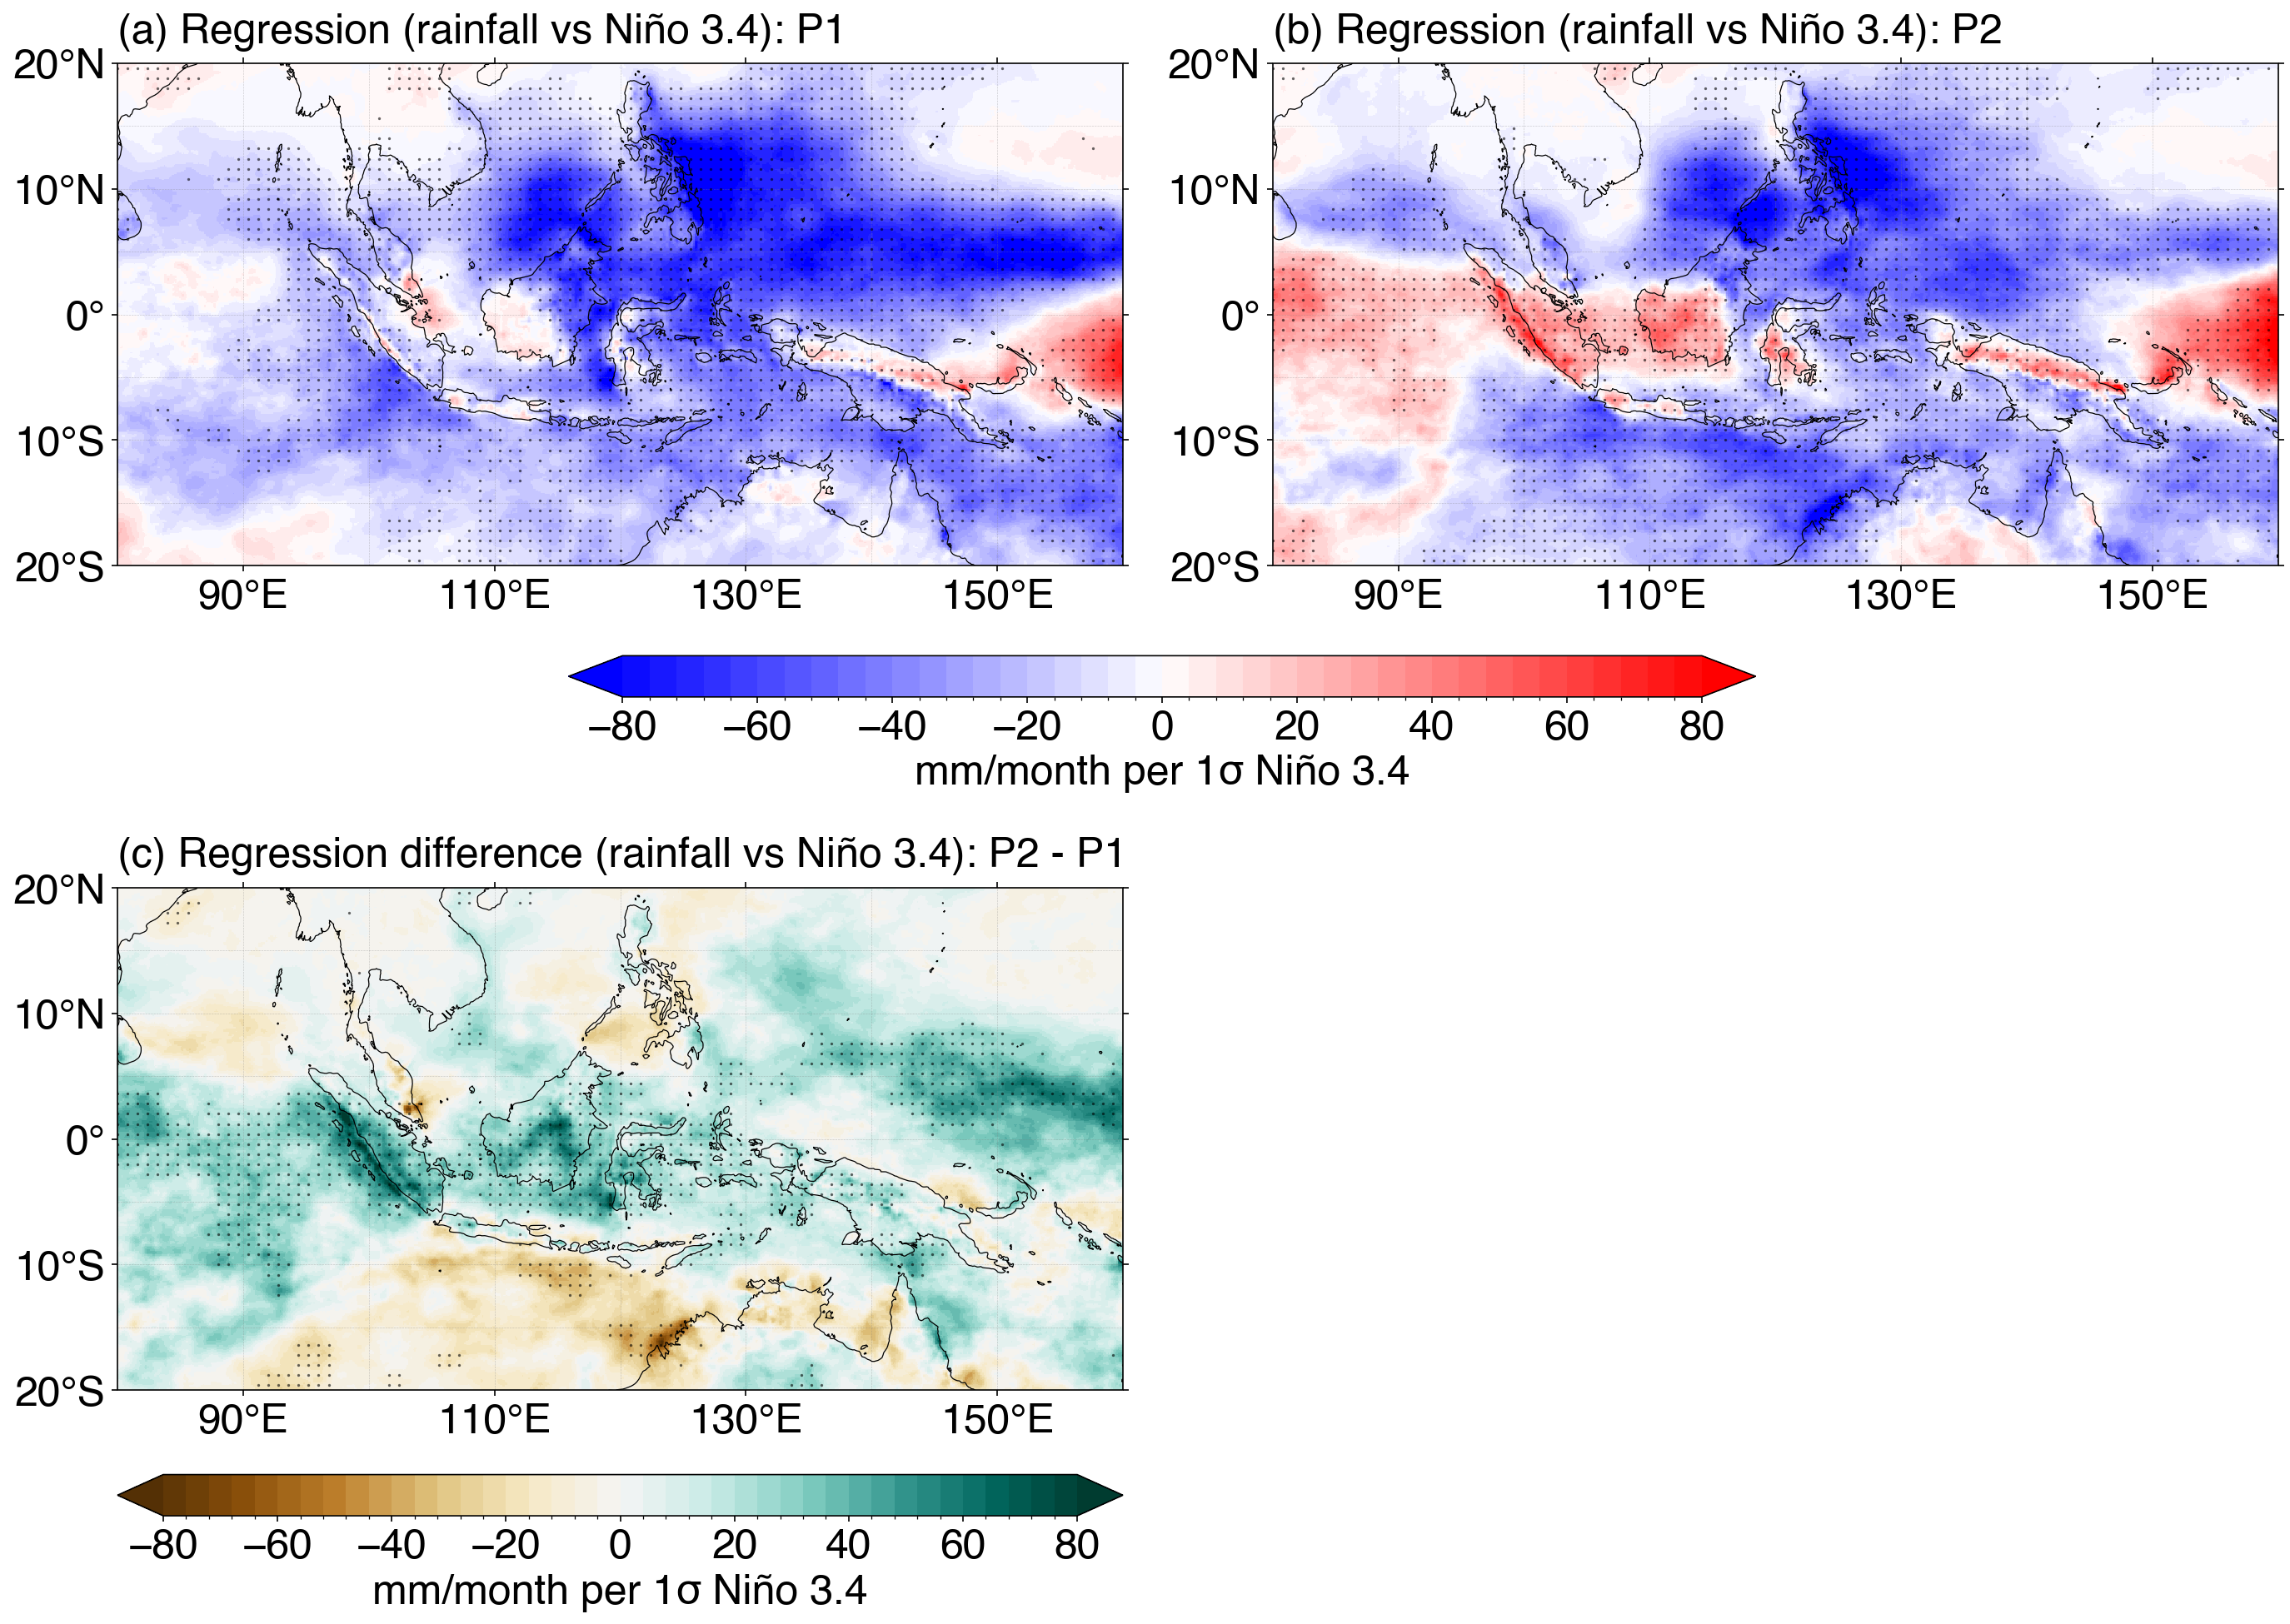

In [3]:
# =========================
# PARAMETER LAYOUT MANUAL
# =========================
# Ubah angka-angka di blok ini kalau ingin mengatur layout tanpa menyentuh kode plot utama.
# Semua posisi/margin memakai koordinat relatif figure: 0 = sisi kiri/bawah, 1 = sisi kanan/atas.

fig_width = 19
fig_height = 15

# Jarak horizontal antara subplot a dan b.
# Naikkan, misalnya 0.18 -> 0.25, kalau label latitude atau peta terasa terlalu dekat.
# Turunkan, misalnya 0.18 -> 0.10, kalau ingin subplot a dan b lebih rapat.
subplot_wspace = 0.35

# Jarak vertikal antara baris atas dan subplot c.
# Naikkan angka ini kalau ingin subplot c lebih turun.
# Turunkan angka ini kalau ingin subplot c lebih dekat ke subplot a-b.
subplot_hspace = 0.1

# Margin keseluruhan figure.
# left/right mengatur batas kiri-kanan semua subplot.
# bottom/top mengatur ruang bawah-atas. Naikkan bottom jika colorbar/tick bawah terpotong.
fig_left = 0.06
fig_right = 0.97
fig_bottom = 0.10
fig_top = 0.94

# Ukuran dan posisi colorbar.
# colorbar_extra_width melebarkan colorbar dari lebar subplot c.
# Contoh: 0.00 = selebar subplot c; 0.08 = lebih lebar 8% figure, dibagi rata kiri-kanan.
colorbar_extra_width = 0.025

# Jarak vertikal colorbar dari subplot c.
# Naikkan angka ini kalau colorbar ingin lebih bawah; turunkan kalau ingin lebih dekat ke subplot c.
colorbar_y_gap = 0.075

# Ketebalan colorbar. Naikkan jika mau colorbar lebih tebal, misalnya 0.032 -> 0.045.
colorbar_height = 0.022

# Label italic r di bawah colorbar.
# colorbar_labelpad mengatur jarak label r dari angka tick colorbar.
# Naikkan kalau r terlalu dekat dengan angka tick; turunkan kalau r terlalu jauh ke bawah.
colorbar_labelpad = 10

fig = plt.figure(figsize=(fig_width, fig_height))
# Layout 2 x 4: subplot a-b melebar di baris atas, subplot c melebar dan terpusat di baris bawah.
# wspace memakai nilai subplot_wspace di atas, jadi cukup ubah variabel itu untuk atur jarak a-b.
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=subplot_hspace, wspace=subplot_wspace)

ax1 = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree(central_longitude=180))
ax2 = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180))
ax3 = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree(central_longitude=180))

subplots = [
    (ax1, rain_reg_past, rain_reg_past_sig, '(a) Regression (rainfall vs Niño 3.4): P1'),
    (ax2, rain_reg_recent, rain_reg_recent_sig, '(b) Regression (rainfall vs Niño 3.4): P2'),
    (ax3, rain_reg_recent_minus_past, rain_reg_recent_minus_past_sig, '(c) Regression difference (rainfall vs Niño 3.4): P2 - P1'),
]

top_img = None
diff_img = None
for ax, data, sig_mask, title in subplots:
    plot_data = smooth_for_plot(data).reset_coords(drop=True)
    img = plot_data.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='BrBG' if ax is ax3 else 'bwr',
        levels=reg_levels,
        extend='both',
        add_colorbar=False,
        add_labels=False,
        infer_intervals=True,
    )
    if ax is ax3:
        diff_img = img
    else:
        top_img = img

    # Signifikansi statistik dengan stippling hitam
    sig_plot = (sig_mask.fillna(False).astype(np.int8).coarsen(lat=8, lon=8, boundary='trim').max() > 0)
    yy, xx = np.where(sig_plot.values)
    if yy.size > 0:
        ax.scatter(
            sig_plot['lon'].values[xx],
            sig_plot['lat'].values[yy],
            s=10,
            c='k',
            marker='.',
            linewidths=0,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

    ax.coastlines(resolution='50m', linewidth=0.6, color='black', zorder=3)
    ax.set_extent(mc_extent, crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    ax.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=24)
    ax.set_title(title, fontweight='bold', loc='left', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Terapkan margin figure.
# Kalau tulisan sisi kiri terpotong, naikkan fig_left sedikit.
# Kalau colorbar/tick bawah terpotong, naikkan fig_bottom sedikit.
fig.subplots_adjust(left=fig_left, right=fig_right, bottom=fig_bottom, top=fig_top)

# Colorbar P1/P2 di antara baris atas dan baris selisih.
fig.canvas.draw()
pos_top_l = ax1.get_position()
pos_bottom = ax3.get_position()

top_cax = fig.add_axes([0.25, pos_top_l.y0 - 0.070, 0.50, colorbar_height])
top_cbar = fig.colorbar(top_img, cax=top_cax, orientation='horizontal', ticks=reg_ticks, spacing='proportional', extend='both')
top_cbar.set_label('mm/month per 1σ Niño 3.4', fontsize=24)

# Colorbar selisih P2 - P1 di bawah panel selisih.
diff_cax = fig.add_axes([pos_bottom.x0, pos_bottom.y0 - 0.067, pos_bottom.width, colorbar_height])
diff_cbar = fig.colorbar(diff_img, cax=diff_cax, orientation='horizontal', ticks=reg_ticks, spacing='proportional', extend='both')
diff_cbar.set_label('mm/month per 1σ Niño 3.4', fontsize=24)

for _cbar in (top_cbar, diff_cbar):
    _cbar.ax.tick_params(labelsize=24)

fig.savefig(RESULTS_DIR / 'rainfall_reg_subplots.png', dpi=300, bbox_inches='tight')
plt.show()
